In [1]:
!pip install -qU pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 112.3 MB/s eta 0:00:00


In [2]:
!pip install -qU langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.8 MB/s eta 0:00:00


In [3]:
from langchain_community.document_loaders import PDFPlumberLoader

loader = PDFPlumberLoader("/content/drive/MyDrive/Colab Notebooks/AI_Peersonal_Finance_Assistant/Bank_Statement_Aarav_Mehta.pdf")
docs = loader.load()
docs[0]

Document(metadata={'source': '/content/drive/MyDrive/Colab Notebooks/AI_Peersonal_Finance_Assistant/Bank_Statement_Aarav_Mehta.pdf', 'file_path': '/content/drive/MyDrive/Colab Notebooks/AI_Peersonal_Finance_Assistant/Bank_Statement_Aarav_Mehta.pdf', 'page': 0, 'total_pages': 2, 'Creator': 'Microsoft® Word 2016', 'CreationDate': "D:20250714214508+00'00'", 'Producer': 'www.ilovepdf.com', 'ModDate': 'D:20250714214508Z'}, page_content='Monthly Bank Statement\nName: Aarav Mehta\nAccount Number: 392159576637\nDate & Time Merchant Reason Amount\n2025-06-01 20:27 Flipkart Online shopping INR 171.06\n2025-06-02 07:03 IRCTC Vacation travel INR 450.40\n2025-06-02 12:40 PhonePe Monthly subscription INR 2315.32\n2025-06-03 06:35 BigBasket Groceries INR 4094.12\n2025-06-04 05:12 PhonePe Mobile recharge INR 4753.26\n2025-06-04 11:34 Uber Work travel INR 236.09\n2025-06-05 04:23 Netflix Monthly subscription INR 3663.09\n2025-06-05 11:58 PhonePe Vacation travel INR 3130.35\n2025-06-05 16:06 Swiggy Food

In [4]:
print(docs[0].metadata)


{'source': '/content/drive/MyDrive/Colab Notebooks/AI_Peersonal_Finance_Assistant/Bank_Statement_Aarav_Mehta.pdf', 'file_path': '/content/drive/MyDrive/Colab Notebooks/AI_Peersonal_Finance_Assistant/Bank_Statement_Aarav_Mehta.pdf', 'page': 0, 'total_pages': 2, 'Creator': 'Microsoft® Word 2016', 'CreationDate': "D:20250714214508+00'00'", 'Producer': 'www.ilovepdf.com', 'ModDate': 'D:20250714214508Z'}


In [5]:
page = []
for doc in loader.lazy_load():
    page.append(doc)
    if len(page) >= 10:
        # do some paged operation, e.g.
        # index.upsert(page)

        page = []
# i want it to see it in a tabuler form


In [7]:
import pdfplumber
import pandas as pd
import re
from datetime import datetime

def extract_transactions_from_pdf(pdf_path):
    """
    Extracts transaction data from the bank statement PDF
    """
    transactions = []

    with pdfplumber.open('/content/drive/MyDrive/Colab Notebooks/AI_Peersonal_Finance_Assistant/Bank_Statement_Aarav_Mehta.pdf') as pdf:
        for page in pdf.pages:
            text = page.extract_text()

            # Extract transactions using regex pattern
            pattern = r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2})\s+\|?\s*([^\|]+?)\s+\|?\s*([^\|]+?)\s+\|?\s*(INR [\d,]+\.\d{2})'
            matches = re.finditer(pattern, text)

            for match in matches:
                date_time, merchant, reason, amount = match.groups()

                # Clean and standardize the data
                transaction = {
                    'date': date_time.split()[0],  # Extract just the date part
                    'time': date_time.split()[1],
                    'merchant': merchant.strip(),
                    'description': reason.strip(),
                    'amount': float(amount.replace('INR ', '').replace(',', '')),
                    'currency': 'INR'
                }
                transactions.append(transaction)

    return transactions

def save_transactions_to_csv(transactions, output_file):
    """
    Saves transactions to a CSV file with proper formatting and returns the DataFrame
    """
    df = pd.DataFrame(transactions)

    # Reorder columns for better readability
    df = df[['date', 'time', 'merchant', 'description', 'amount', 'currency']]

    # Convert date string to datetime object for proper sorting
    df['date'] = pd.to_datetime(df['date'])

    # Sort by date and time
    df = df.sort_values(['date', 'time'])

    # Convert back to string for CSV output
    df['date'] = df['date'].dt.strftime('%Y-%m-%d')

    # Save to CSV
    df.to_csv(output_file, index=False)
    print(f"Successfully saved {len(df)} transactions to {output_file}")

    return df # Return the DataFrame


def main():
    # Input and output file paths
    pdf_file = "/content/Bank_Statement_Aarav_Mehta.pdf"
    csv_file = "Aarav_Mehta_Transactions_June_2025.csv"

    # Process the PDF
    transactions = extract_transactions_from_pdf(pdf_file)

    # Save to CSV and get the DataFrame
    df = save_transactions_to_csv(transactions, csv_file)

    return df # Return the DataFrame from main

if __name__ == "__main__":
    df = main() # Assign the returned DataFrame to df in the global scope

Successfully saved 40 transactions to Aarav_Mehta_Transactions_June_2025.csv


In [8]:
df.head()
df.drop(columns=['currency'], inplace=True)


In [10]:
df.head()

,date,time,merchant,description,amount,category
0,2025-06-01,20:27,Flipkart,Online shopping,171.06,Shopping
1,2025-06-02,07:03,IRCTC,Vacation travel,450.40,Transport & Travel
2,2025-06-02,12:40,PhonePe,Monthly subscription,2315.32,Subscriptions
3,2025-06-03,06:35,BigBasket,Groceries,4094.12,Shopping
4,2025-06-04,05:12,PhonePe,Mobile recharge,4753.26,Subscriptions


In [9]:


# Create categorization function
def categorize_transaction(row):
    description = row['description'].lower()
    merchant = row['merchant'].lower()

    # Food-related
    if any(keyword in description or keyword in merchant
           for keyword in ['food', 'zomato', 'swiggy', 'grocery']):
        return 'Food & Dining'

    # Shopping
    elif any(keyword in description or keyword in merchant
             for keyword in ['shopping', 'amazon', 'flipkart', 'bigbasket']):
        return 'Shopping'

    # Travel
    elif any(keyword in description or keyword in merchant
             for keyword in ['travel', 'uber', 'irctc']):
        return 'Transport & Travel'

    # Subscriptions
    elif any(keyword in description or keyword in merchant
             for keyword in ['subscription', 'netflix', 'phonepe', 'google play']):
        return 'Subscriptions'

    # Entertainment
    elif any(keyword in merchant for keyword in ['netflix']):
        return 'Entertainment'

    # Utilities
    elif any(keyword in description for keyword in ['mobile recharge']):
        return 'Utilities'

    else:
        return 'Other'

# Apply categorization
df['category'] = df.apply(categorize_transaction, axis=1)

# Save the categorized data
df.to_csv('categorized_transactions.csv', index=False)
df.head()
# what are the data in the catagory coulumn
df['category'].unique()

array(['Shopping', 'Transport & Travel', 'Subscriptions', 'Food & Dining',
       'Other'], dtype=object)

In [11]:
# 1. Basic Spending Overview
total_spent = df['amount'].sum()
avg_transaction = df['amount'].mean()
transaction_count = len(df)

print(f"Total Spent: ₹{total_spent:,.2f}")
print(f"Average Transaction: ₹{avg_transaction:,.2f}")
print(f"Number of Transactions: {transaction_count}")

# 2. Category Breakdown
category_stats = df.groupby('category').agg(
    total_spent=('amount', 'sum'),
    transaction_count=('amount', 'count'),
    avg_transaction=('amount', 'mean')
).sort_values('total_spent', ascending=False)

print("\nSpending by Category:")
print(category_stats)

# 3. Percentage Breakdown
category_stats['percentage'] = (category_stats['total_spent'] / total_spent) * 100
print("\nPercentage by Category:")
print(category_stats[['percentage']])

Total Spent: ₹103,730.68
Average Transaction: ₹2,593.27
Number of Transactions: 40

Spending by Category:
                    total_spent  transaction_count  avg_transaction
category                                                           
Food & Dining          39434.43                 11      3584.948182
Shopping               26753.62                 11      2432.147273
Transport & Travel     21842.85                 10      2184.285000
Subscriptions          14193.78                  7      2027.682857
Other                   1506.00                  1      1506.000000

Percentage by Category:
                    percentage
category                      
Food & Dining        38.016168
Shopping             25.791424
Transport & Travel   21.057271
Subscriptions        13.683300
Other                 1.451837


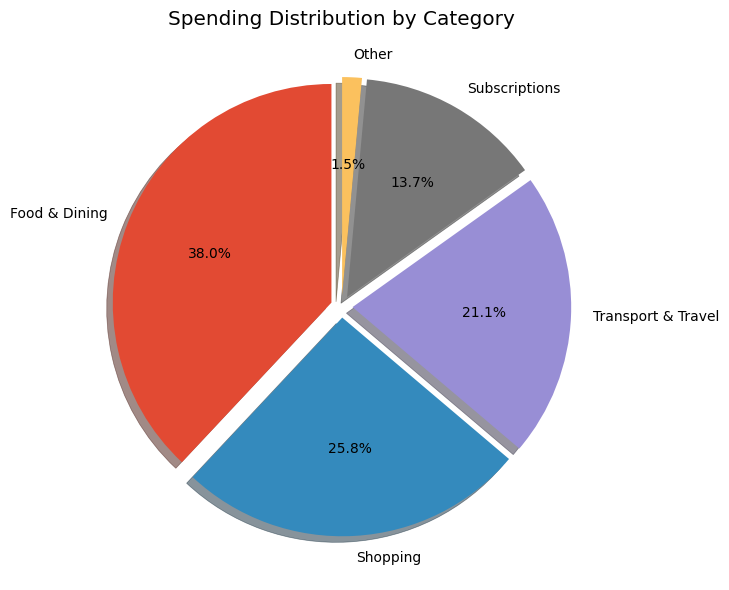

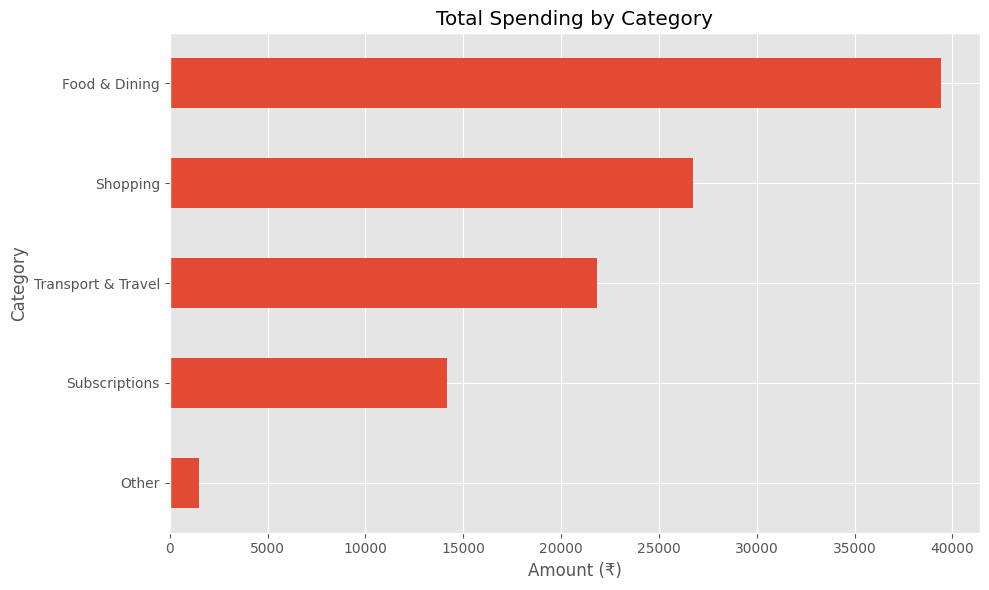

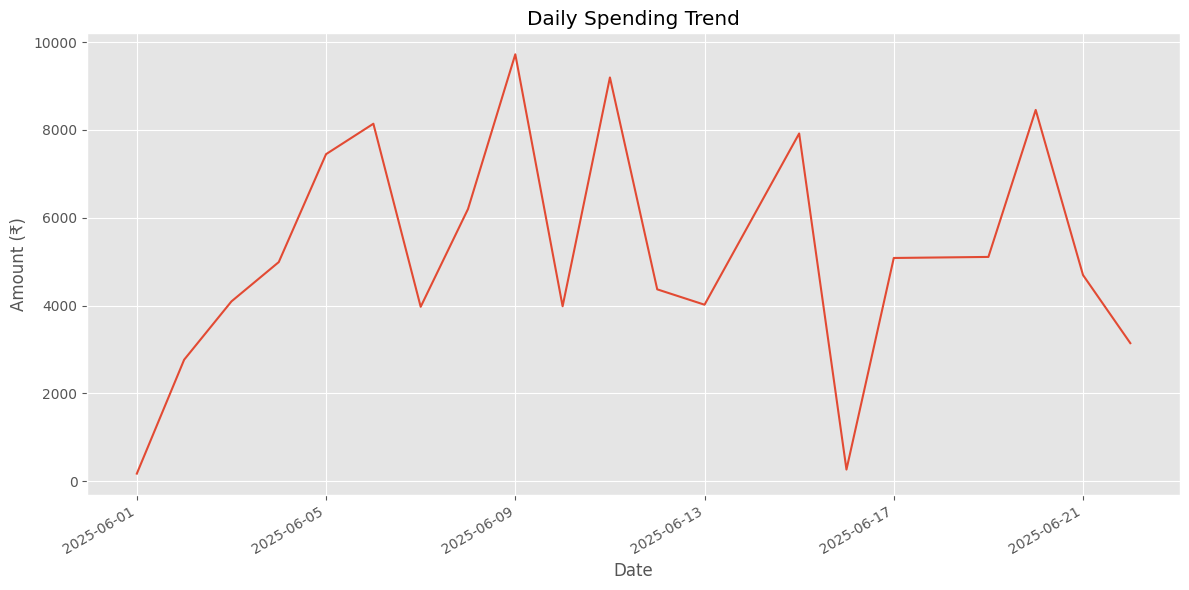

<Figure size 1200x600 with 0 Axes>

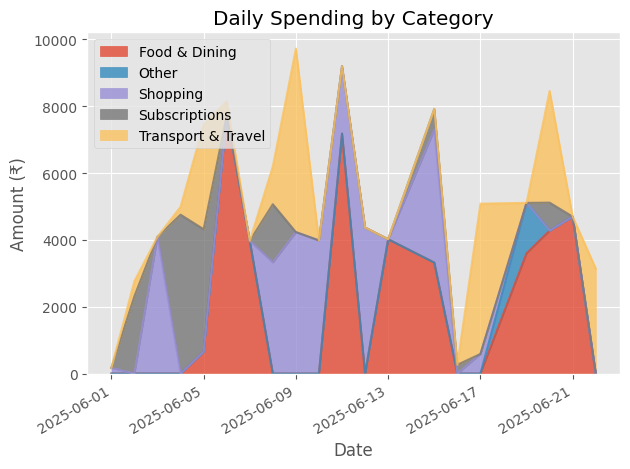

In [12]:
import matplotlib.pyplot as plt

# Set style
plt.style.use('ggplot')

# 1. Pie Chart of Categories
plt.figure(figsize=(10, 6))
category_stats['total_spent'].plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]*len(category_stats),
    shadow=True
)
plt.title('Spending Distribution by Category')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 2. Bar Chart of Categories
plt.figure(figsize=(10, 6))
category_stats['total_spent'].sort_values().plot.barh()
plt.title('Total Spending by Category')
plt.xlabel('Amount (₹)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# 3. Daily Spending Trend
df['date'] = pd.to_datetime(df['date'])
daily_spending = df.groupby('date')['amount'].sum()

plt.figure(figsize=(12, 6))
daily_spending.plot()
plt.title('Daily Spending Trend')
plt.ylabel('Amount (₹)')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Category Trends Over Time (Advanced)
category_daily = df.groupby(['date', 'category'])['amount'].sum().unstack()

plt.figure(figsize=(12, 6))
category_daily.plot.area(stacked=True, alpha=0.8)
plt.title('Daily Spending by Category')
plt.ylabel('Amount (₹)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


Top 5 Largest Transactions:
         date   merchant           description   amount            category
4  2025-06-04    PhonePe       Mobile recharge  4753.26       Subscriptions
38 2025-06-21  BigBasket         Food delivery  4694.26       Food & Dining
32 2025-06-17       Uber                Travel  4496.65  Transport & Travel
36 2025-06-20     Zomato  Monthly subscription  4277.88       Food & Dining
16 2025-06-09     Amazon       Online shopping  4232.44            Shopping

Most Frequent Merchants:
merchant
Zomato     6
Uber       6
Amazon     5
PhonePe    5
Swiggy     4
Name: count, dtype: int64


/tmp/ipython-input-13-2765112356.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['time']).dt.hour


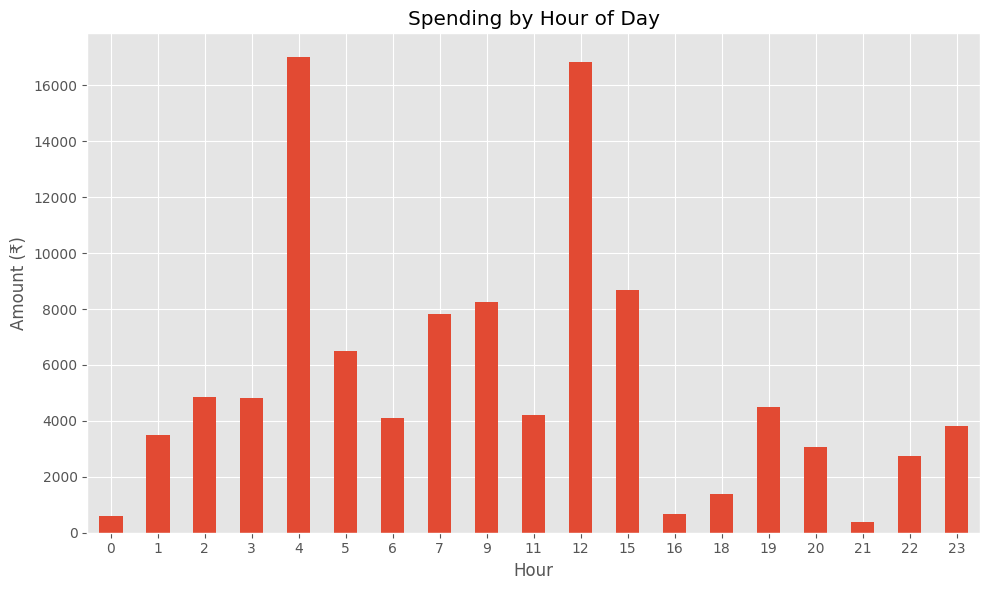

In [13]:
# Find largest transactions
top_transactions = df.sort_values('amount', ascending=False).head(5)
print("\nTop 5 Largest Transactions:")
print(top_transactions[['date', 'merchant', 'description', 'amount', 'category']])

# Find most frequent merchants
frequent_merchants = df['merchant'].value_counts().head(5)
print("\nMost Frequent Merchants:")
print(frequent_merchants)

# Find spending patterns by time of day
df['hour'] = pd.to_datetime(df['time']).dt.hour
time_spending = df.groupby('hour')['amount'].sum()

plt.figure(figsize=(10, 6))
time_spending.plot.bar()
plt.title('Spending by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# Generate a text report
with open('spending_analysis_report.txt', 'w') as f:
    f.write("=== Personal Spending Analysis Report ===\n\n")
    f.write(f"Period: {df['date'].min()} to {df['date'].max()}\n")
    f.write(f"Total Spent: ₹{total_spent:,.2f}\n")
    f.write(f"Average Daily Spend: ₹{total_spent/len(df['date'].unique()):,.2f}\n\n")

    f.write("=== By Category ===\n")
    f.write(category_stats.to_string())

    f.write("\n\n=== Recommendations ===\n")
    for category, row in category_stats.iterrows():
        if row['percentage'] > 20:  # If category >20% of spending
            f.write(f"• Your spending on {category} is {row['percentage']:.1f}% of total. Consider reviewing these expenses.\n")

    if len(top_transactions[top_transactions['amount'] > 3000]) > 5:
        f.write("\n• You have several large transactions (>₹3000). Review if these were all necessary.\n")

print("Analysis report saved as 'spending_analysis_report.txt'")


Analysis report saved as 'spending_analysis_report.txt'


In [15]:
df.head()
# lets standerdize the data
# standerdizing amount by min max  score method
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# df['amount'] = scaler.fit_transform(df[['amount']])
# df['hour'] = scaler.fit_transform(df[['hour']])
# df.head()
# # replacing this as the final csv file
# df.to_csv('categorized_transactions.csv', index=False)


,date,time,merchant,description,amount,category,hour
0,2025-06-01,20:27,Flipkart,Online shopping,171.06,Shopping,20
1,2025-06-02,07:03,IRCTC,Vacation travel,450.40,Transport & Travel,7
2,2025-06-02,12:40,PhonePe,Monthly subscription,2315.32,Subscriptions,12
3,2025-06-03,06:35,BigBasket,Groceries,4094.12,Shopping,6
4,2025-06-04,05:12,PhonePe,Mobile recharge,4753.26,Subscriptions,5


<Axes: xlabel='amount', ylabel='Count'>

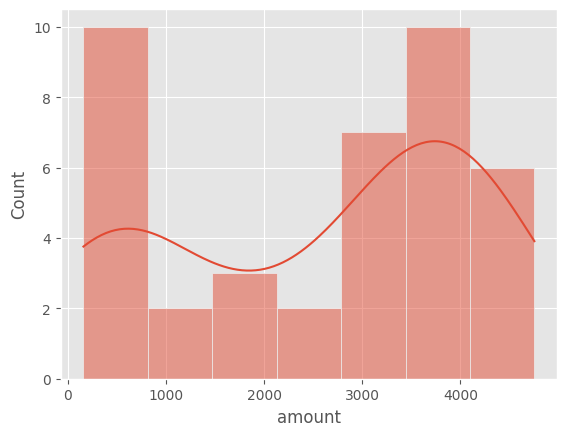

In [16]:
# now checking if the data is normally distributable or not
import seaborn as sns
sns.histplot(df['amount'], kde=True)

In [21]:
df.head()
db1=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AI_Peersonal_Finance_Assistant/expense_data.csv')

db2=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AI_Peersonal_Finance_Assistant/expense_forecast_data.csv')
db3=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AI_Peersonal_Finance_Assistant/budget_data.csv')
db3.head()


,income,saving,expenses
0,1171.06,1000,171.06
1,4765.72,2000,2765.72
2,5294.12,1200,4094.12
3,7489.35,2500,4989.35
4,10448.03,3000,7448.03
